In [2]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.max_rows', 40)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


/var/folders/60/t8rss6wj7db2zq0ltd58sfhm0000gp/T/ipykernel_95095/3819027835.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(mt,mt+meal_duration,color="#b4d2e6",lw=2,zorder=0,edgecolor='#396cb6')


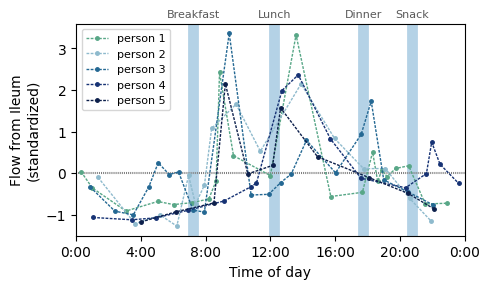

In [3]:
# Import dataset
phillips=pd.read_csv("phillips_1973_flowdata.csv")

# Set up figure panel
fig, ax = plt.subplots(1,1,figsize=(5,3))

# Format the x axis as time of day (clock time)
def hhmm(x,_pos):
    x=x%24
    h=int(x)
    m=int(round((x-h)*60))
    if m==60:
        h+=1; m=0
    return "%d:%02d"%(h,m)

ax.set_xlabel("time of day")
ax.set_xlim(0,24)
ax.set_xticks(np.arange(0,25,4))
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(hhmm))
ax.set_ylabel("flow (ml/min)")

# Color palette from MoMA Van Gogh color palette
colorlist=[ "#58a787", "#8ebacd", "#246893", "#163274", "#0C1F4b"]

# Plot meal provision times (each meal ~30 min, shown as a shaded band)
meal_duration=0.5  # h
meals=[(7.0,"Breakfast"),(12.0,"Lunch"),(17.5,"Dinner"),(20.5,"Snack")]
for mt,name in meals:
    ax.axvspan(mt,mt+meal_duration,color="#b4d2e6",lw=2,zorder=0,edgecolor='#396cb6')
    ax.text(mt+0.5*meal_duration,1.02,name,transform=ax.get_xaxis_transform(),ha="center",va="bottom",fontsize=8,color="0.35")

# Plot flow into the cecum for all participants
for p in [1,2,3,4,5]:
    y=phillips["person"+str(p)+"_flow_mL_min"]

    # Standardize flow measurements for each person
    y_standardized = (y-np.mean(y))/np.std(y)

    # Plot standardized flow
    ax.plot(phillips["person"+str(p)+"_time_hr"],y_standardized,linestyle=(0, (2,1)),markersize=5,marker='.',linewidth=1,color=colorlist[p-1],zorder=3,label="person "+str(p))

# Set up axes
ax.axhline(y=0,color='gray',linestyle=(0, (0.5,0.5)),zorder=0)
ax.legend(fontsize=8,loc='upper left')
ax.set_ylabel('Flow from Ileum\n(standardized)')
ax.set_xlabel('Time of day')

# Save figure
fig.tight_layout()
plt.show()
fig.savefig("flowdata_standardized.pdf", dpi=1000,transparent=True)
